In [1]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import pandas as pd
import numpy as np
from yllib.function import myfunc
from yllib.plot import plot_map
from cartopy import crs as ccrs
import matplotlib.pyplot as plt
import matplotlib as mpl
%config InlineBackend.figure_format='retina'

In [2]:
loc_Humboldt = [-124.5907, 40.97]
loc_Morro    = [-121.8581, 35.7107]

In [3]:
obs_Humboldt = xr.open_dataset('../obs/lidar.z05.a0.20201008_20220601.nc')['wind_speed'] # Humboldt
obs_Morro    = xr.open_dataset('../obs/lidar.z06.a0.20200929_20211016.nc')['wind_speed'] # Humboldt
obs_Humboldt.name = 'Humboldt'
obs_Morro.name = 'Morro'
data = xr.merge([obs_Humboldt, obs_Morro])
data = data
print(data.time)
obs_hourly = data.resample(time='1h').mean()
print(obs_hourly)

<xarray.DataArray 'time' (time: 73708)> Size: 590kB
array(['2020-09-29T00:00:00.000000000', '2020-09-29T00:10:00.000000000',
       '2020-09-29T00:20:00.000000000', ..., '2022-06-01T23:40:00.000000000',
       '2022-06-01T23:50:00.000000000', '2022-06-02T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 590kB 2020-09-29 ... 2022-06-02
Attributes:
    standard_name:  time
    long_name:      Time (UTC)
    axis:           T
<xarray.Dataset> Size: 3MB
Dimensions:   (height: 12, time: 14665)
Coordinates:
  * height    (height) float64 96B 40.0 60.0 80.0 90.0 ... 200.0 220.0 240.0
  * time      (time) datetime64[ns] 117kB 2020-09-29 ... 2022-06-02
Data variables:
    Humboldt  (time, height) float64 1MB nan nan nan nan ... 8.16 8.11 8.13 8.15
    Morro     (time, height) float64 1MB 2.406 2.534 2.534 2.518 ... nan nan nan
Attributes:
    long_name:            Wind Speed
    units:                m/s
    ancillary_variables:  qc_wind_speed


In [4]:
np.unique(obs_hourly.time).size

14665

In [5]:
ds = xr.open_dataset('../ERA/uvp.sfc.2019_2022.nc')
uv = np.sqrt(ds['u100']**2+ds['v100']**2)
era_Humboldt = uv.sel(longitude=loc_Humboldt[0], latitude=loc_Humboldt[1], method='nearest')
era_Morro    = uv.sel(longitude=loc_Morro[0],    latitude=loc_Morro[1], method='nearest')


In [6]:
lat = np.load(f'hrrr_lat.npy')
lon = np.load(f'hrrr_lon.npy') - 360.

def find_location(lat, lon, site):
    distance = np.sqrt((lat-site[1])**2+(lon-site[0])**2)
    xy = np.argmin(distance)
    return np.unravel_index(xy, distance.shape)

xy_Humboldt = find_location(lat, lon, loc_Humboldt)
xy_Morro    = find_location(lat, lon, loc_Morro)

print(xy_Humboldt)
print(xy_Morro)


lisa_uv = xr.open_dataarray('results_v3.1/pred.lisa3.1.nc').drop_duplicates('time')
print(lisa_uv.shape)
lisa_Humboldt = lisa_uv[:,*xy_Humboldt]
lisa_Morro    = lisa_uv[:,*xy_Morro]

lisa_uv_4hr = xr.open_dataarray('results_v3.1_4hr/pred.lisa3.1_4hr.nc').drop_duplicates('time')
lisa_4hr_Humboldt = lisa_uv_4hr[:,*xy_Humboldt]
lisa_4hr_Morro    = lisa_uv_4hr[:,*xy_Morro]

unet_uv = xr.open_dataarray('results_unet/pred.unet.nc').drop_duplicates('time')
unet_Humboldt = unet_uv[:,*xy_Humboldt]
unet_Morro    = unet_uv[:,*xy_Morro]

hrrr_uv = xr.open_dataarray('ground_truth/pred.gt.nc').drop_duplicates('time')
hrrr_Humboldt = hrrr_uv[:,*xy_Humboldt]
hrrr_Morro    = hrrr_uv[:,*xy_Morro]

# v1_Humboldt = xr.concat(v1_Humboldt, dim='hour')
# v1_Morro    = xr.concat(v1_Morro, dim='hour')
# v1_Humboldt.coords['hour'] = time
# v1_Morro.coords['hour'] = time

# v1_Humboldt.to_netcdf('ts_v1_Humboldt.nc')
# v1_Morro.to_netcdf('ts_v1_Morro.nc')


(401, 120)
(191, 143)
(8757, 670, 260)


In [8]:
def calculate_stats(model_data, obs_data, period):
    """Calculate bias, correlation, and RMSE for a given model and observation data."""
    model_period = model_data.sel(time=slice(*period))
    obs_period = obs_data.sel(time=slice(*period))

    time_intersection = np.intersect1d(model_period.time, obs_period.time)
    model_period = model_period.sel(time=time_intersection)
    obs_period = obs_period.sel(time=time_intersection)


    if model_period.time.size == 0 or obs_period.time.size == 0:
        return np.nan, np.nan, np.nan

    mean = obs_period.mean().values
    bias = (model_period - obs_period).mean().values
    correlation = xr.corr(model_period, obs_period).values
    rmse = xr.apply_ufunc(np.sqrt, ((model_period - obs_period)**2).mean()).values
    
    return mean, bias, correlation, rmse

def plot_model_data(data, period, style, color, label, ax):
    """Plot model data with specified style."""
    data.sel(time=slice(*period)).plot(ax=ax, ls=style, c=color, label=label)

def plot_and_stats(period, site, exprs=('hrrr', 'unet', 'lisa', 'era'), fig=None, ax=None, **kwargs):
    """Plot time series comparison and calculate statistics for different models."""
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(10,5), dpi=100)
    
    stats = {}
    
    stats['period'] = f"{period[0]} to {period[1]}"
    stats['site'] = site
    # Define model configurations
    model_configs = {
        'hrrr': {'style': '-', 'color': 'tab:orange', 'label': 'HRRR'},
        'lisa': {'style': ':', 'color': 'blue', 'label': 'LISA-2hr'},
        'lisa_4hr': {'style': '--', 'color': 'blue', 'label': 'LISA-4hr'},
        'unet': {'style': '--', 'color': 'black', 'label': 'UNet'},
        'era': {'style': '-', 'color': 'gray', 'label': 'ERA5'}
    }
    
    # Get site-specific data
    if site == 'Humboldt':
        model_data = {
            'hrrr': hrrr_Humboldt,
            'lisa': lisa_Humboldt,
            'lisa_4hr': lisa_4hr_Humboldt,
            'unet': unet_Humboldt,
            'era': era_Humboldt
        }
        obs_data = obs_hourly['Humboldt']
        height = 80
    elif site == 'Morro':
        model_data = {
            'hrrr': hrrr_Morro,
            'lisa': lisa_Morro,
            'lisa_4hr': lisa_4hr_Morro,
            'unet': unet_Morro,
            'era': era_Morro
        }
        obs_data = obs_hourly['Morro']
        height = 80
    else:
        raise ValueError(f"Unknown site: {site}")
    
    # Plot models and calculate stats
    for expr in exprs:
        if expr in model_configs:
            config = model_configs[expr]
            data = model_data[expr]
            
            # Plot model data
            plot_model_data(data, period, config['style'], config['color'], config['label'], ax)
            
            # Calculate statistics
            mean, bias, correlation, rmse = calculate_stats(data, obs_data.sel(height=height), period)
            stats[f'mean'] = mean
            stats[f'{expr}_bias'] = bias
            stats[f'{expr}_correlation'] = correlation
            stats[f'{expr}_rmse'] = rmse
    
    # Plot observations
    obs_data.sel(height=height).sel(time=slice(*period)).plot(
        ax=ax, ls='-', c='tab:red', label='Lidar', alpha=0.7
    )
    
    # Customize plot
    if kwargs.get('draw_legend', False): ax.legend(ncol=2)
    ax.set_title(f'{site} Wind Speed Comparison')
    ax.set_title('')
    ax.set_ylabel('Wind Speed (m/s)')
    
    return fig, ax, stats

In [9]:
STATS = {}

def stats_to_dataframe(stats_dict):
    """Convert STATS dictionary to pandas DataFrame."""
    if not stats_dict:
        return pd.DataFrame()
    
    # Convert to list of dictionaries with casename
    rows = []
    for casename, stats in stats_dict.items():
        row = {'casename': casename}
        row.update(stats)
        rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Reorder columns to have casename, period, site first
    if len(df) > 0:
        base_cols = ['casename', 'period', 'site']
        other_cols = [col for col in df.columns if col not in base_cols]
        df = df[base_cols + sorted(other_cols)]
    
    return df

# Function to display final results
def show_final_stats():
    """Display STATS as a formatted DataFrame."""
    df = stats_to_dataframe(STATS)
    print("Final Statistics Summary:")
    print("=" * 80)
    return df

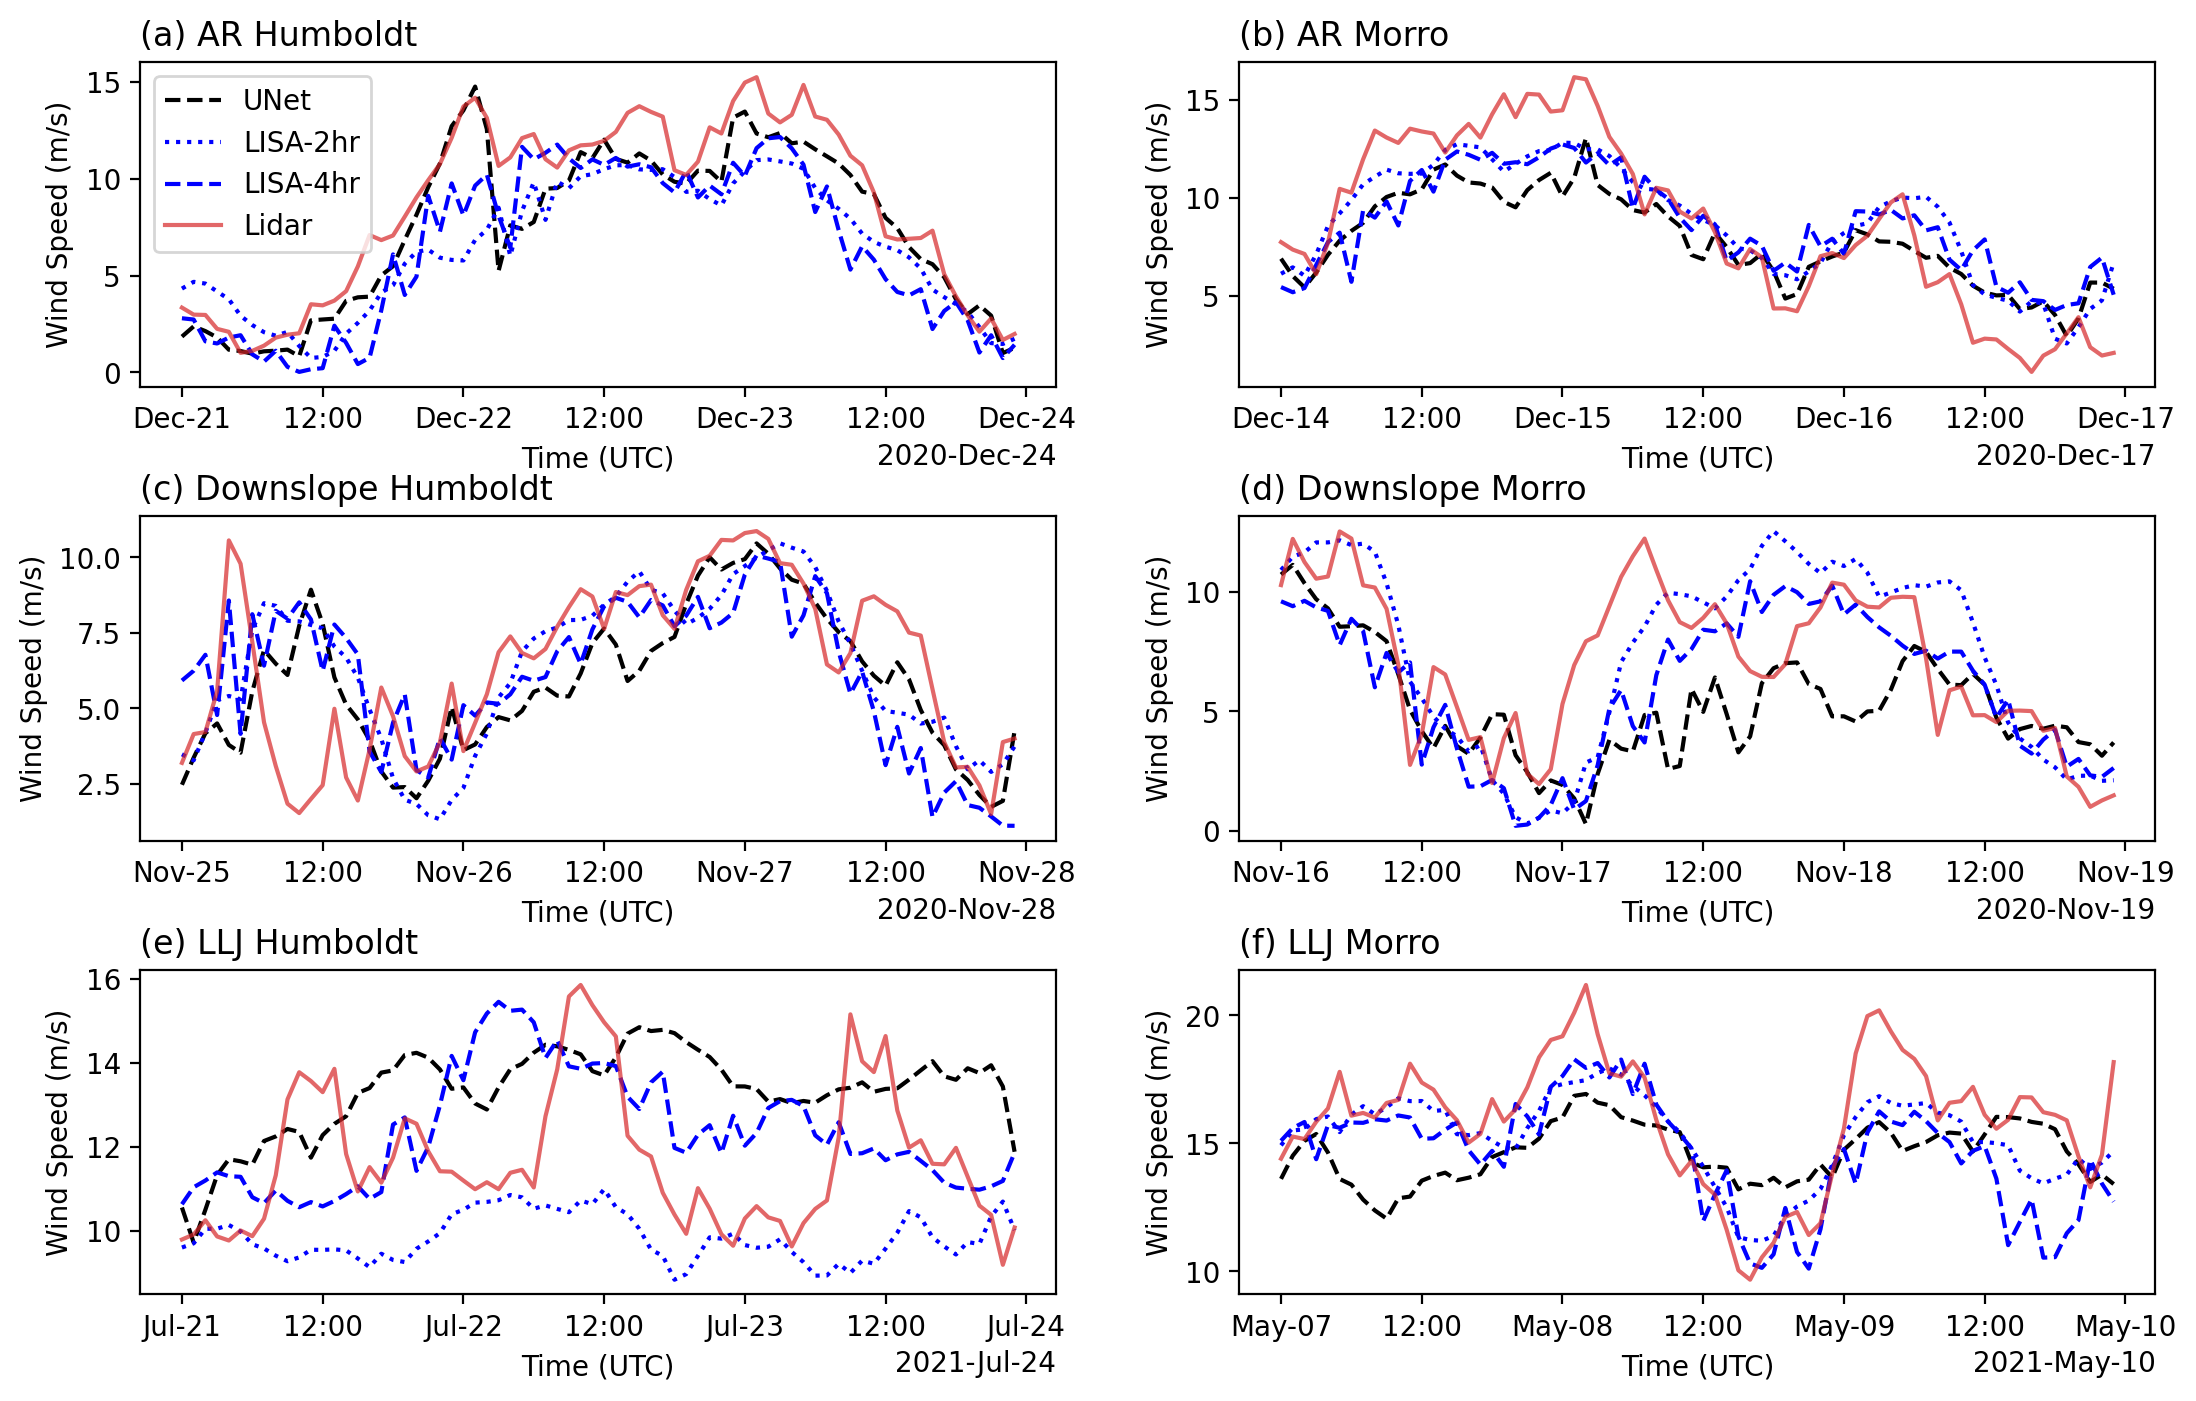

In [10]:
fig, axs = plt.subplots(3, 2, figsize=(13,8), dpi=100)
plt.subplots_adjust(hspace=0.4, wspace=0.2)
axs = axs.ravel()

cases = [
    (('2020-12-21','2020-12-23'), 'Humboldt', 'AR_Humboldt'),
    (('2020-12-14','2020-12-16'), 'Morro', 'AR_Morro'),
    (('2020-11-25','2020-11-27'), 'Humboldt', 'Downslope_Humboldt'),
    (('2020-11-16','2020-11-18'), 'Morro', 'Downslope_Morro'),
    (('2021-07-21','2021-07-23'), 'Humboldt', 'LLJ_Humboldt'),
    (('2021-05-07','2021-05-09'), 'Morro', 'LLJ_Morro')
]

abcd = list('abcdef')
STATS1 = {}
for i, (ax, case) in enumerate(zip(axs, cases)):
    period, site, casename = case
    _, _, stats = plot_and_stats(period, site, exprs=('unet', 'lisa', 'lisa_4hr'), fig=fig, ax=ax)
    if i==0: ax.legend(ncol=1)
    STATS1[casename] = stats
    ax.set_title(f"({abcd[i]}) {casename.replace('_', ' ')}", loc='left')
df = stats_to_dataframe(STATS1)
df

plt.savefig('figure_comparison_ts.png', dpi=300, bbox_inches='tight')
